In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2

In [8]:
import pickle
import xarray

import numpy as np
from zipfile import ZipFile

import linodenet
import matplotlib.pyplot as plt
import torch

from typing import Sized
from tqdm import tqdm, trange
from pathlib import Path
import pandas
from pandas import DataFrame

In [9]:
df = pandas.read_hdf(Path.cwd().parent.joinpath('data/some_data_from_db.h5'))
df = df.drop(columns="unit")

measurement_id   Acetate  Acid  Base  \
experiment_id measurement_time                                         
8627          0.0                     13418568       NaN   NaN   NaN   
              0.0                     13418576       NaN   NaN   NaN   
              0.0                     13418616  0.156787   NaN   NaN   
              0.0                     13418624  0.156787   NaN   NaN   
              950255.0                13400808       NaN   NaN   NaN   
...                                        ...       ...   ...   ...   
8664          28000.0                 13585193       NaN   NaN   NaN   
              28009.0                 13585217       NaN   NaN   NaN   
              28010.0                 13585241       NaN   NaN   NaN   
              1208063.0               13624609       NaN   NaN   NaN   
              1208243.0               13624633       NaN   NaN   NaN   

                                Cumulated_feed_volume_acetate  \
experiment_id measurement_time                                  
8627          0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              950255.0                                    NaN   
...                                                       ...   
8664          28000.0                                     NaN   
              28009.0                                     NaN   
              28010.0                                     NaN   
              1208063.0                                   NaN   
              1208243.0                                   NaN   

                                Cumulated_feed_volume_glucose  \
experiment_id measurement_time                                  
8627          0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              950255.0                                    NaN   
...                                                       ...   
8664          28000.0                                     NaN   
              28009.0                                     NaN   
              28010.0                                     NaN   
              1208063.0                                   NaN   
              1208243.0                                   NaN   

                                Cumulated_feed_volume_medium        DOT  \
experiment_id measurement_time                                            
8627          0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              950255.0                                   NaN   7.460000   
...                                                      ...        ...   
8664          28000.0                                    NaN        NaN   
              28009.0                                    NaN  40.330002   
              28010.0                                    NaN        NaN   
              1208063.0                                  NaN        NaN   
              1208243.0                                  NaN        NaN   

                                Enzyme_addition    Glucose   OD600  \
experiment_id measurement_time                                       
8627          0.0                           NaN  -7.206886     NaN   
              0.0                           NaN -14.505053     NaN   
              0.0                           NaN        NaN     NaN   
              0.0                           NaN        NaN     NaN   
       

In [10]:
data = df.loc[8627].reset_index().set_index("measurement_time")

,measurement_id,Acetate,Acid,Base,Cumulated_feed_volume_acetate,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Enzyme_addition,Glucose,OD600,Probe_Volume,pH
measurement_time,,,,,,,,,,,,,
0.0,13418568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.206886,NaN,NaN,NaN
0.0,13418576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14.505053,NaN,NaN,NaN
0.0,13418616,0.156787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.0,13418624,0.156787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
950255.0,13400808,NaN,NaN,NaN,NaN,NaN,NaN,7.46,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1267376.0,13471800,NaN,NaN,NaN,NaN,NaN,NaN,2.78,NaN,NaN,NaN,NaN,NaN
1267376.0,13471824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.55
1267436.0,13471848,NaN,NaN,NaN,NaN,NaN,NaN,2.53,NaN,NaN,NaN,NaN,NaN


In [11]:
from typing import Union, Optional, Callable, Iterator
from torch.utils.data import Sampler
from numpy.random import Generator



# TODO: add exclusive_args decorator
class SequentialSliceSampler(Sampler):
    r"""
    
    Default modus operandi:
    
    - Use fixed window size
    - Sample starting index uniformly from [0:-window]
    
    Should you want to sample windows of varying size, you may supply a 
    """
    def __init__(self, data, slice_sampler: Optional[Union[int, Callable[[], int]]], sampler: Optional[Callable[[], tuple[int, int]]] = None):
        super().__init__(data)
        self.data = data
        self.rng = np.random.default_rng()
        self.idx = np.arange(len(data))
        self.slice_sampler = slice_sampler if callable(slice_sampler) else (lambda: slice_sampler)

        def sampler() -> tuple[int, int]:
            window_size = self.slice_sampler()
            start_index = self.rng.choice(self.idx[:-window_size])
            return window_size, start_index

        self.sampler = sampler
        
    
    def __iter__(self) -> Iterator:
        while True:
            # sample len and index
            window_size, start_index = self.sampler()
            # return slice
            yield self.data.iloc[start_index: start_index+window_size]
    
    

In [12]:
from tsdm.util.dtypes import TimeDeltaLike, TimeStampLike

In [13]:
# TODO: add exclusive_args decorator
class TimeSliceSampler(Sampler):
    r"""Sample by time.

    Default modus operandi:

    - Use fixed window size
    - Sample starting index uniformly from [0:-window]

    Should you want to sample windows of varying size, you may supply a
    """

    def __init__(
        self,
        data_source: Optional[Sized],
        slice_sampler: Optional[Union[TimeDeltaLike, Callable[[], TimeDeltaLike]]],
        sampler: Optional[Callable[[], tuple[TimeDeltaLike, TimeStampLike]]] = None,
    ):
        """Initialize Sampler.

        Parameters
        ----------
        data_source
        slice_sampler
        sampler
        """
        super().__init__(data_source)
        self.data = DataFrame(data_source)
        self.idx = np.arange(len(data_source))

        self.rng = np.random.default_rng()
        self.slice_sampler = (
            slice_sampler if callable(slice_sampler) else (lambda: slice_sampler)
        )

        def sampler() -> tuple[int, int]:
            window_size = self.slice_sampler()
            start_index = self.rng.choice(self.idx[:-window_size])
            return window_size, start_index

        self.sampler = sampler

    def __iter__(self) -> Iterator:
        r"""Yield random window from dataset

        Returns
        -------

        """
        while True:
            # sample len and index
            window_size, start_index = self.sampler()
            # return slice
            yield self.data.iloc[start_index : start_index + window_size]

In [15]:
full, slc = data, data.iloc[[0,1,2,7,99,101], [1,5,4]]

In [17]:
sampler = torch.utils.data.SequentialSampler(full)
dloader = torch.utils.data.dataloader.DataLoader(full, sampler=sampler)

In [18]:
xarray.DataArray(full, dims=["obs time", "obs val"], name="run 1").to_dataframe().memory_usage()

Index    195814
run 1    309400
dtype: int64

In [19]:
xarray.Dataset(coords = {"full":xarray.DataArray(full), "slc":xarray.DataArray(slc)})

ValueError: cannot reindex or align along dimension 'measurement_time' because the index has duplicate values

KeyError: 'measurement_time'

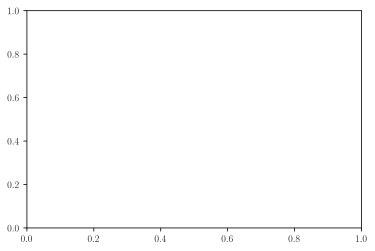

In [20]:
fig, ax = plt.subplots()

for col in ("Acetate", "Acid", "Base", "DOT"):
    line = ax.plot(data["measurement_time"].iloc[6:-100], data[col].iloc[6:-100])
    
ax.legend(["Acetate", "Acid", "Base", "DOT"])

In [ ]:
ds = torch.tensor(data.values)

In [ ]:
sampler = BatchSampler(SequentialSampler(ds), batch_size=32, drop_last=True)
from torch import Tensor            
def collate_list(batch: list[Tensor]) -> list[Tensor]:
    r"""Collates list of tensors as list of tensors."""
    return batch

In [ ]:

dloader = DataLoader(TensorDataset(ds), batch_sampler=sampler)

idloader = iter(dloader)
next(idloader), next(idloader)



In [ ]:
list(iter(SequentialSampler(ds)))

In [ ]:
dir(tsdm)

In [ ]:
import numpy

In [ ]:
dir(numpy)